In [1]:
# Cell 1: Imports and Setup
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import quantus
import h5py
import os

2024-08-03 15:35:10.767454: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-03 15:35:10.789012: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-03 15:35:10.806110: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-03 15:35:10.811261: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-03 15:35:10.824908: I tensorflow/core/platform/cpu_feature_guar

In [2]:

# Cell 2: Load Model
model = tf.keras.models.load_model('../results_50E/alexnet_audio_model.h5')


In [3]:
# Cell 3: Data Loading Function
def load_test_data(data_path, num_samples=8):
    X = []
    y = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.startswith('AlexNet') and file.endswith('.hdf5'):
                file_path = os.path.join(root, file)
                with h5py.File(file_path, 'r') as f:
                    X.append(f['data'][:])
                    y.append(f['label'][:, 0])
                if len(X) >= num_samples:
                    break
        if len(X) >= num_samples:
            break
    return np.concatenate(X, axis=0)[:num_samples], np.array(y)[:num_samples]


In [4]:
# Load the model
model = tf.keras.models.load_model('../results_50E/alexnet_audio_model.h5')

# Load a small batch of data
data_path = '/home/mqa887/tmp/audiomnist/AudioMNIST-master'
x_batch, y_batch = load_test_data(data_path, num_samples=8)
x_batch = (x_batch - np.mean(x_batch)) / np.std(x_batch)  # Normalize

# Reshape the input to match the model's expected input shape
x_batch = np.transpose(x_batch, (0, 2, 3, 1))  # Change from (batch, 1, 227, 227) to (batch, 227, 227, 1)

# Ensure x_batch is in the correct shape
print("x_batch shape:", x_batch.shape)

# Make a prediction to ensure the model is working
y_batch
y_pred_raw = model(x_batch)
y_pred_classes = np.argmax(y_pred_raw, axis=1)

print("Raw Predictions shape:", y_pred_raw.shape)
print("Predicted Classes:", y_pred_classes)
print("True classes:", y_batch)

x_batch shape: (8, 227, 227, 1)
Raw Predictions shape: (8, 10)
Predicted Classes: [6 9 9 5 5 1 3 0]
True classes: [[6]
 [9]
 [9]
 [5]
 [5]
 [1]
 [3]
 [0]]


In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout

def create_alexnet_functional(input_shape=(227, 227, 1), num_classes=10):
    inputs = Input(shape=input_shape)
    
    x = Conv2D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = MaxPooling2D(pool_size=3, strides=2)(x)
    x = Conv2D(256, kernel_size=5, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=3, strides=2)(x)
    x = Conv2D(384, kernel_size=3, padding='same', activation='relu')(x)
    x = Conv2D(384, kernel_size=3, padding='same', activation='relu')(x)
    x = Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=3, strides=2)(x)
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)  # Changed from 4096 to 1024
    x = Dropout(0.5)(x)
    x = Dense(1024, activation='relu')(x)  # Changed from 4096 to 1024
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Recreate the model architecture
input_shape = (227, 227, 1)
new_model = create_alexnet_functional(input_shape=input_shape, num_classes=10)

# Load the weights from the saved model
new_model.load_weights('../results_50E/alexnet_audio_model.h5')

# Verify the new model
print("New model summary:")
new_model.summary()

print("\nMaking a prediction with new model:")
sample_prediction = new_model.predict(x_batch[:1])
print("Sample prediction shape:", sample_prediction.shape)
print("Sample prediction:", sample_prediction)

New model summary:


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 227, 227, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        11,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,222,026 (54.25 MB)

 Trainable params: 14,222,026 (54.25 MB)

 Non-trainable params: 0 (0.00 B)


Making a prediction with new model:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Sample prediction shape: (1, 10)
Sample prediction: [[6.9426254e-10 5.0115702e-12 8.2418149e-11 2.4036950e-10 2.2979424e-11
  2.1390774e-10 9.9999988e-01 6.7351694e-11 1.1520518e-07 3.1113545e-10]]


In [6]:
print("y_pred_classes shape:", y_pred_classes.shape)
print("y_pred_classes dtype:", y_pred_classes.dtype)

y_pred_classes shape: (8,)
y_pred_classes dtype: int64


In [13]:
print("Min value in a_batch:", np.min(a_batch))
print("Max value in a_batch:", np.max(a_batch))
print("Mean value in a_batch:", np.mean(a_batch))
print("Std dev of a_batch:", np.std(a_batch))
print("Number of zero values in a_batch:", np.sum(a_batch == 0))
print("Number of NaN values in a_batch:", np.sum(np.isnan(a_batch)))

Min value in a_batch: 0.0
Max value in a_batch: 0.996078431372549
Mean value in a_batch: 0.000684375712286894
Std dev of a_batch: 0.008159139224439477
Number of zero values in a_batch: 402352
Number of NaN values in a_batch: 0


Custom Complexity Scores: [ 8.61123631 10.84989488 10.84989488 10.84989488 10.84989488 10.84989488
 10.84989488 10.84989488]
Mean Complexity: 10.570062560882047
Std Complexity: 0.7403667306773628
Min Complexity: 8.61123631252381
Max Complexity: 10.84989488207608

Mean absolute attribution: 0.000684375712286894
Max absolute attribution: 0.996078431372549
Min absolute attribution: 0.0
Std of absolute attribution: 0.008159139224439477


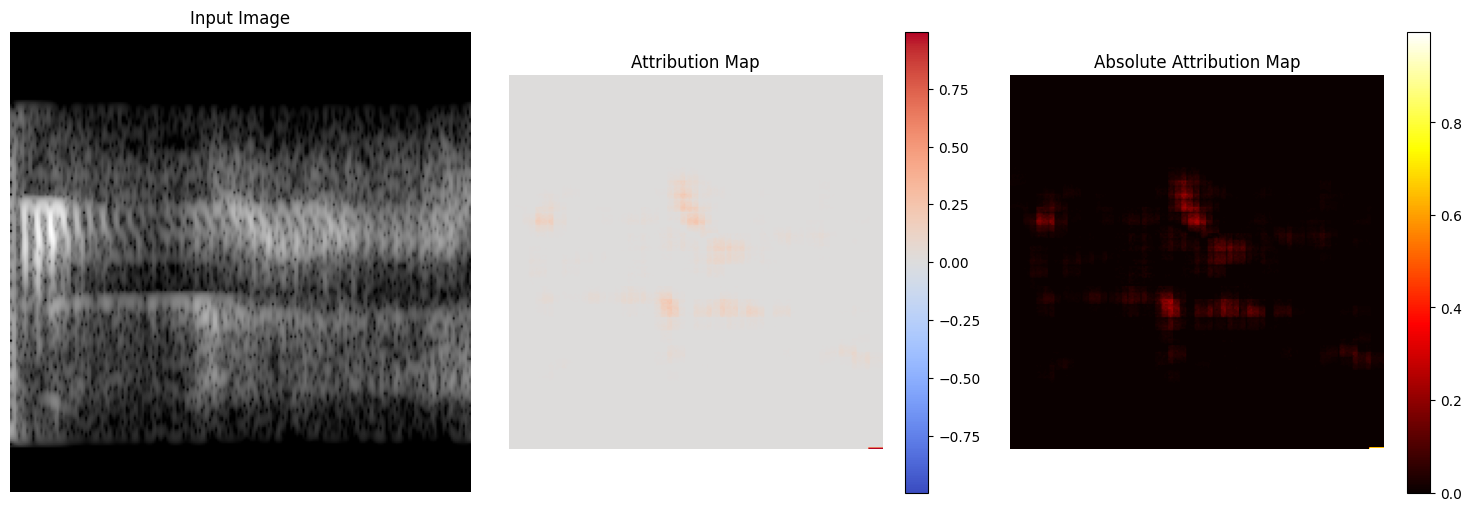

In [14]:
def custom_complexity_metric(a_batch, epsilon=1e-10):
    # Flatten each attribution map
    flat_attributions = a_batch.reshape(a_batch.shape[0], -1)
    
    # Normalize the flattened attributions, adding a small epsilon to avoid division by zero
    abs_sum = np.sum(np.abs(flat_attributions), axis=1, keepdims=True)
    normalized_attributions = np.where(abs_sum > epsilon,
                                       flat_attributions / (abs_sum + epsilon),
                                       1.0 / flat_attributions.shape[1])
    
    # Calculate entropy for each sample
    entropies = -np.sum(normalized_attributions * np.log(normalized_attributions + epsilon), axis=1)
    
    return entropies

# Use the custom metric
complexity_scores = custom_complexity_metric(a_batch)
print("Custom Complexity Scores:", complexity_scores)
print("Mean Complexity:", np.mean(complexity_scores))
print("Std Complexity:", np.std(complexity_scores))
print("Min Complexity:", np.min(complexity_scores))
print("Max Complexity:", np.max(complexity_scores))

# Calculate some basic statistics on the absolute attribution values
abs_attributions = np.abs(a_batch)
print("\nMean absolute attribution:", np.mean(abs_attributions))
print("Max absolute attribution:", np.max(abs_attributions))
print("Min absolute attribution:", np.min(abs_attributions))
print("Std of absolute attribution:", np.std(abs_attributions))

# Visualize one of the attribution maps
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(x_batch_reshaped[0], cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(a_batch[0], cmap='coolwarm', vmin=-np.max(np.abs(a_batch[0])), vmax=np.max(np.abs(a_batch[0])))
plt.title('Attribution Map')
plt.colorbar()
plt.axis('off')

plt.subplot(133)
plt.imshow(np.abs(a_batch[0]), cmap='hot', vmin=0, vmax=np.max(np.abs(a_batch[0])))
plt.title('Absolute Attribution Map')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
print("Mean absolute attribution:", np.mean(np.abs(a_batch)))
print("Max absolute attribution:", np.max(np.abs(a_batch)))
print("Min absolute attribution:", np.min(np.abs(a_batch)))
print("Std of absolute attribution:", np.std(np.abs(a_batch)))

Mean absolute attribution: 0.000684375712286894
Max absolute attribution: 0.996078431372549
Min absolute attribution: 0.0
Std of absolute attribution: 0.008159139224439477


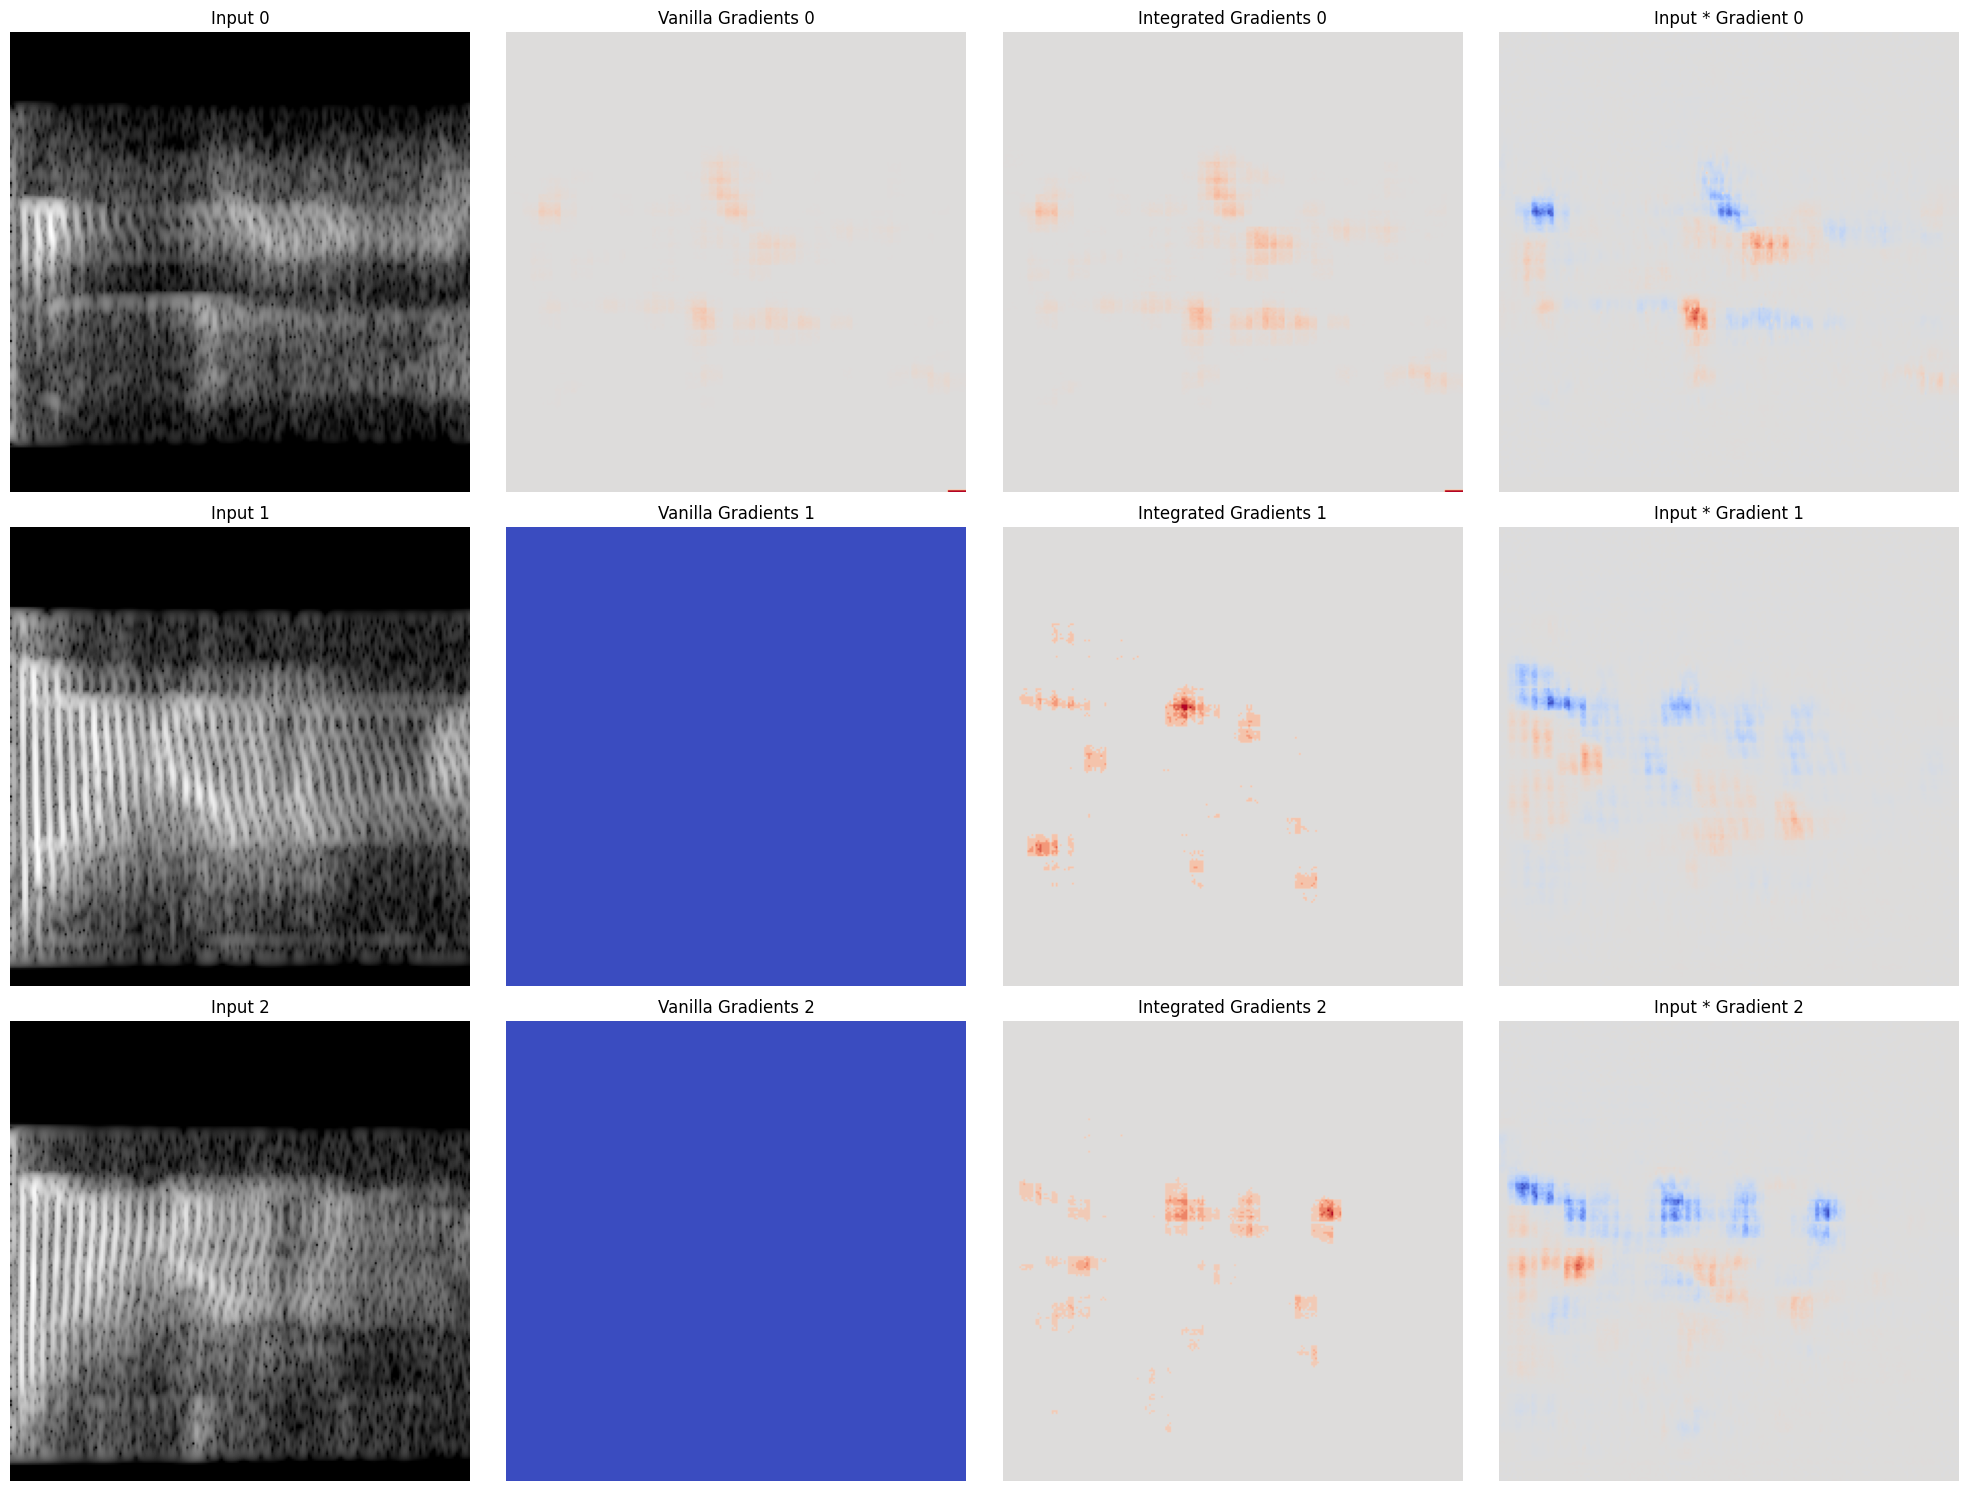

In [16]:
import quantus
import matplotlib.pyplot as plt

# Try Integrated Gradients
ig_attributions = quantus.explain(
    model=new_model,
    inputs=x_batch_reshaped,
    targets=y_pred_classes,
    method="IntegratedGradients"
)

# Simple input-times-gradient method
def input_times_gradient(model, inputs, targets):
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        predictions = model(inputs)
        loss = tf.gather_nd(predictions, tf.stack([tf.range(predictions.shape[0]), targets], axis=1))
    grads = tape.gradient(loss, inputs)
    return inputs * grads

itg_attributions = input_times_gradient(new_model, tf.convert_to_tensor(x_batch_reshaped), y_pred_classes)

# Visualize results for the first 3 samples
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
for i in range(3):
    axs[i, 0].imshow(x_batch_reshaped[i], cmap='gray')
    axs[i, 0].set_title(f'Input {i}')
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(a_batch[i], cmap='coolwarm', vmin=-np.max(np.abs(a_batch[i])), vmax=np.max(np.abs(a_batch[i])))
    axs[i, 1].set_title(f'Vanilla Gradients {i}')
    axs[i, 1].axis('off')
    
    axs[i, 2].imshow(ig_attributions[i], cmap='coolwarm', vmin=-np.max(np.abs(ig_attributions[i])), vmax=np.max(np.abs(ig_attributions[i])))
    axs[i, 2].set_title(f'Integrated Gradients {i}')
    axs[i, 2].axis('off')
    
    axs[i, 3].imshow(itg_attributions[i], cmap='coolwarm', vmin=-np.max(np.abs(itg_attributions[i])), vmax=np.max(np.abs(itg_attributions[i])))
    axs[i, 3].set_title(f'Input * Gradient {i}')
    axs[i, 3].axis('off')

plt.tight_layout()
plt.show()

In [17]:
import quantus
import numpy as np
import tensorflow as tf

def get_attributions(model, inputs, targets):
    return quantus.explain(
        model=model,
        inputs=inputs,
        targets=targets,
        method="IntegratedGradients",
        explain_func_kwargs={"n_steps": 50, "baseline": "zero"}
    )

# Generate attributions for your dataset
a_batch = get_attributions(new_model, x_batch_reshaped, y_pred_classes)

In [20]:
import quantus
import numpy as np
import tensorflow as tf

def get_attributions(model, inputs, targets):
    return quantus.explain(
        model=model,
        inputs=inputs,
        targets=targets,
        method="IntegratedGradients",
        explain_func_kwargs={"n_steps": 50, "baseline": "zero"}
    )

# Generate attributions for your dataset
a_batch = get_attributions(new_model, x_batch_reshaped, y_pred_classes)

# Common parameters for all metrics
common_params = {
    "abs": True,
    "normalise": True,
    "return_aggregate": True,
    "perturb_func": "gaussian_noise",
}

# 1. MaxSensitivity
max_sen = quantus.MaxSensitivity(**common_params)
max_sen_scores = max_sen(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 2. AvgSensitivity
avg_sen = quantus.AvgSensitivity(**common_params)
avg_sen_scores = avg_sen(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 3. Relative Input Stability
ris = quantus.RelativeInputStability(**common_params)
ris_scores = ris(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 4. Relative Output Stability
ros = quantus.RelativeOutputStability(**common_params)
ros_scores = ros(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 5. Relative Representation Stability (all layers)
rrs = quantus.RelativeRepresentationStability(**common_params)
rrs_scores = rrs(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 6. RRS(layer_names=top_conv)
# Assuming 'top_conv' is the name of your top convolutional layer
rrs_top_conv = quantus.RelativeRepresentationStability(**common_params, layer_names=['top_conv'])
rrs_top_conv_scores = rrs_top_conv(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# 7. RRS(layer_indices=3, 4, 5)
rrs_layers = quantus.RelativeRepresentationStability(**common_params, layer_indices=[3, 4, 5])
rrs_layers_scores = rrs_layers(
    model=new_model,
    x_batch=x_batch_reshaped,
    y_batch=y_pred_classes,
    a_batch=a_batch,
    channel_first=False,
    explain_func=get_attributions,
    nr_samples=10  # Add this parameter here
)

# Print results
print("MaxSensitivity Score:", max_sen_scores)
print("AvgSensitivity Score:", avg_sen_scores)
print("Relative Input Stability Score:", ris_scores)
print("Relative Output Stability Score:", ros_scores)
print("Relative Representation Stability Score (all layers):", rrs_scores)
print("RRS(layer_names=top_conv) Score:", rrs_top_conv_scores)
print("RRS(layer_indices=3, 4, 5) Score:", rrs_layers_scores)

TypeError: the first argument must be callable